<a href="https://colab.research.google.com/github/oscmoral/Programacion-para-analitica-descriptiva-y-predictiva/blob/main/proyecto_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proyecto Final

Nombre: Oscar Morales Martinez

Matrícula: 266223

Materia: Programación para analítica descriptiva y predictiva

Carrera: Maestría en Inteligencia Artificial y Analítica de Datos

## Descripción del dataset

- **Nombre**: House Prices — Advanced Regression Techniques
- **Fuente**: Kaggle
- **Enlace**: https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques

## Tipo de problema

Regresión

## Pregunta de negocio:

¿Es posible predecir el precio de una vivienda utilizando características estructurales y de ubicación de la propiedad?

## Exploración inicial (EDA)

### Importar librerías y asignar estilos

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")
sns.set_palette("deep")

sns.set_context("paper")

sns.despine()

<Figure size 1000x600 with 0 Axes>

### Acceso a Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Carga del dataset

In [ ]:
path = "/content/drive/MyDrive/ClassFiles/train.csv"

df = pd.read_csv(path)

### Primeras filas

In [ ]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


### Información general

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

### Shape del dataset

In [ ]:
print("Filas:", df.shape[0])
print("Columnas:", df.shape[1])

Filas: 1460
Columnas: 81


### Estadísticas descriptivas

In [ ]:
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


### Tipos de variables

In [ ]:
df.dtypes.value_counts()

,count
object,43
int64,35
float64,3


### Valores faltantes

In [ ]:
missing_values = df.isnull().sum().sort_values(ascending=False)

missing_values[missing_values > 0].head(20)

,0
PoolQC,1453
MiscFeature,1406
Alley,1369
Fence,1179
MasVnrType,872
FireplaceQu,690
LotFrontage,259
GarageQual,81
GarageFinish,81
GarageType,81


### Visualización de valores faltantes

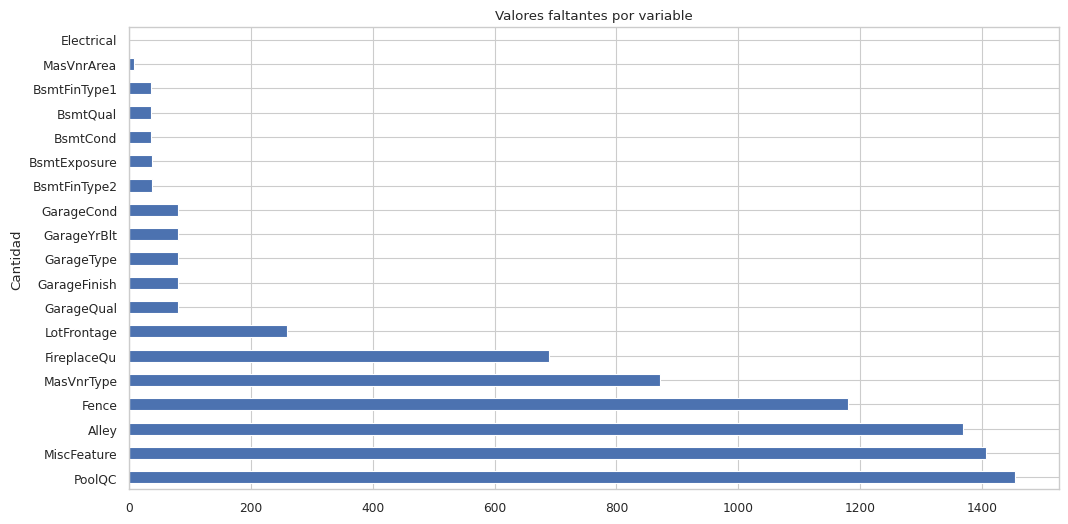

In [ ]:
plt.figure(figsize=(12,6))

missing_values[missing_values > 0].plot(kind="barh")

plt.title("Valores faltantes por variable")
plt.ylabel("Cantidad")

plt.show()

### Distribución de SalePrice

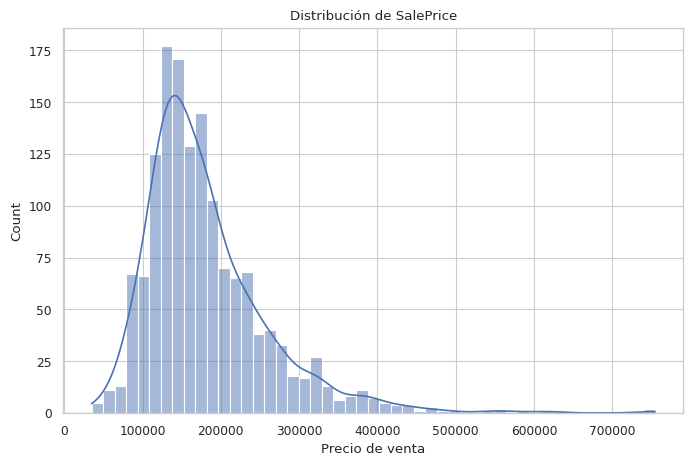

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(df["SalePrice"], kde=True)

plt.title("Distribución de SalePrice")
plt.xlabel("Precio de venta")

plt.show()

### Boxplot de SalePrice

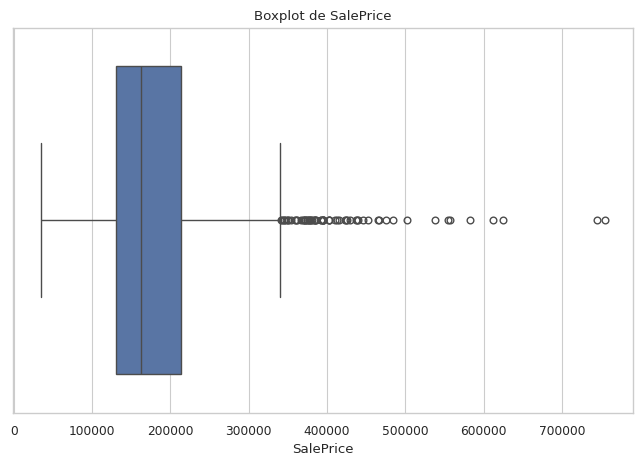

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df["SalePrice"])

plt.title("Boxplot de SalePrice")

plt.show()

### Correlación con SalePrice

In [ ]:
numeric_df = df.select_dtypes(include=["int64", "float64"])

correlations = numeric_df.corr()["SalePrice"].sort_values(ascending=False)

correlations.head(15)

,SalePrice
SalePrice,1.000000
OverallQual,0.790982
GrLivArea,0.708624
GarageCars,0.640409
GarageArea,0.623431
TotalBsmtSF,0.613581
1stFlrSF,0.605852
FullBath,0.560664
TotRmsAbvGrd,0.533723
YearBuilt,0.522897


### Heatmap de correlaciones

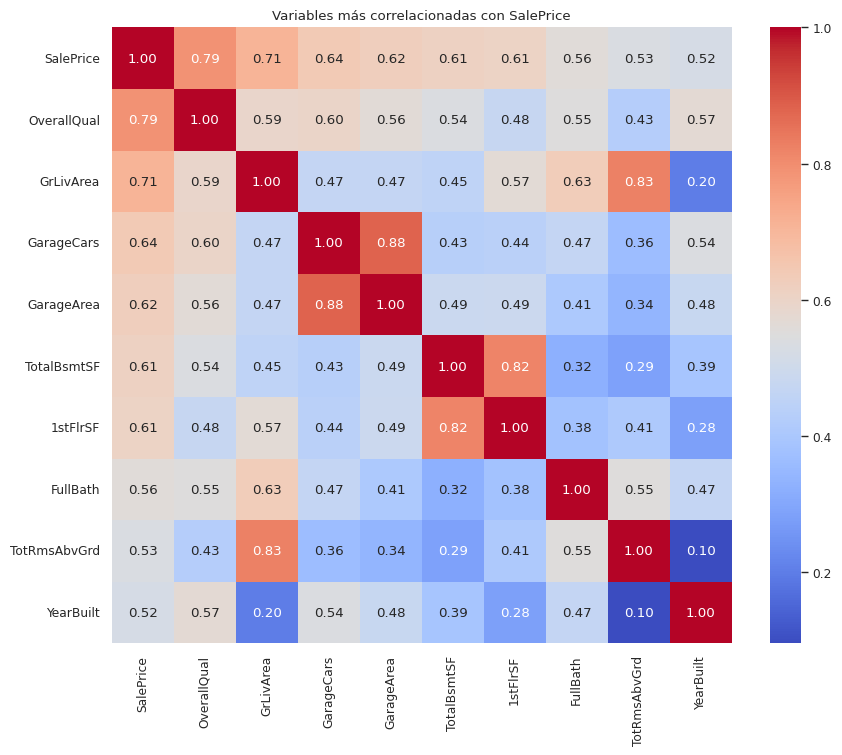

In [ ]:
top_corr = correlations.index[:10]

plt.figure(figsize=(10,8))

sns.heatmap(
    df[top_corr].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Variables más correlacionadas con SalePrice")

plt.show()

### Scatterplot OverallQual vs SalePrice

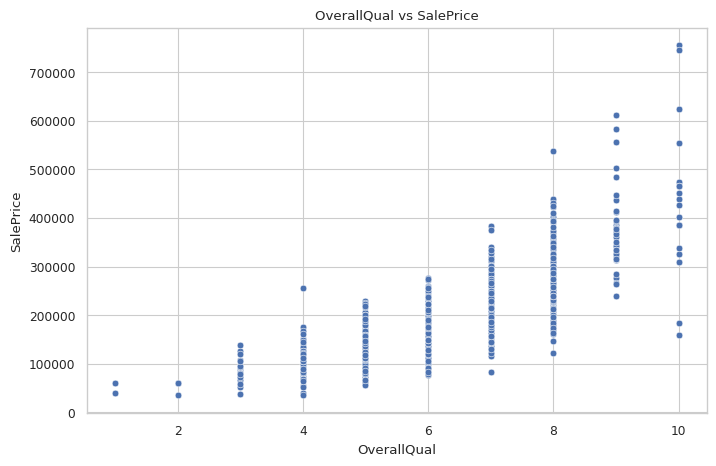

In [ ]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="OverallQual",
    y="SalePrice"
)

plt.title("OverallQual vs SalePrice")

plt.show()

### Scatterplot GrLivArea vs SalePrice

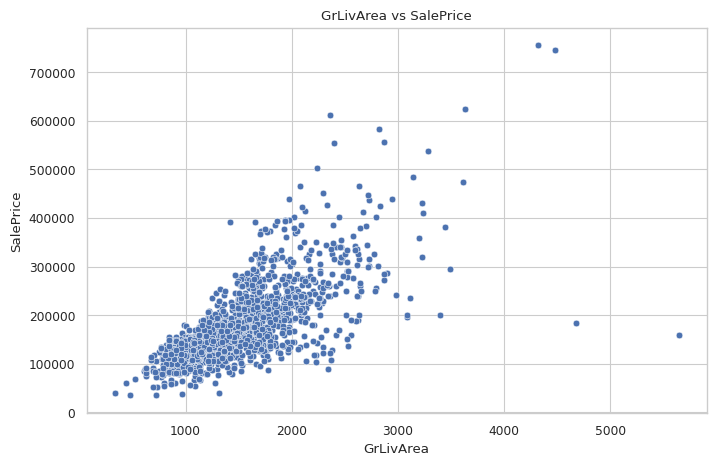

In [ ]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="GrLivArea",
    y="SalePrice"
)

plt.title("GrLivArea vs SalePrice")

plt.show()

## Preprocesamiento

### Definir X e y

In [ ]:
X = df.drop(columns=["SalePrice"])
y = df["SalePrice"]

### Train/Test split

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

### Variables numéricas y categóricas

In [ ]:
numeric_cols = X_train.select_dtypes(
    include=["int64", "float64"]
).columns

categorical_cols = X_train.select_dtypes(
    include=["object"]
).columns

print("Numéricas:", len(numeric_cols))
print("Categóricas:", len(categorical_cols))

Numéricas: 37
Categóricas: 43


### Importar transformadores

In [ ]:
from sklearn.impute import SimpleImputer

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

### Pipeline numérico

In [ ]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

### Pipeline categórico

In [ ]:
categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

### ColumnTransformer

In [ ]:
preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_cols),
    ("cat", categorical_transformer, categorical_cols)
])

## Modelos seleccionados

Se entrenarán dos modelos distintos:

- Random Forest
- Gradient Boosting

Estos modelos permitirán comparar desempeño y capacidad de generalización.

### Importar modelos

In [ ]:
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)

### Pipeline Random Forest (Base)

In [ ]:
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),

    ("model", RandomForestRegressor(
        random_state=42
    ))
])

### Pipeline Gradient Boosting (Base)

In [ ]:
gb_pipeline = Pipeline([
    ("preprocessor", preprocessor),

    ("model", GradientBoostingRegressor(
        random_state=42
    ))
])

### Entrenamiento del modelo Random Forest Base

In [ ]:
rf_pipeline.fit(X_train, y_train)

rf_pred = rf_pipeline.predict(X_test)

### Entrenamiento del modelo Gradient Boosting Base

In [ ]:
gb_pipeline.fit(X_train, y_train)

gb_pred = gb_pipeline.predict(X_test)

### Importar métricas

In [ ]:
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

### Función de evaluación

In [ ]:
def regression_metrics(y_true, y_pred):

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    return rmse, mae, r2

### Métricas Random Forest Base

In [ ]:
rf_rmse, rf_mae, rf_r2 = regression_metrics(
    y_test,
    rf_pred
)

print("Random Forest Base")
print("RMSE:", rf_rmse)
print("MAE:", rf_mae)
print("R2:", rf_r2)

Random Forest Base
RMSE: 28527.52033809099
MAE: 17546.713424657533
R2: 0.8939002860298636


### Métricas Gradient Boosting Base

In [ ]:
gb_rmse, gb_mae, gb_r2 = regression_metrics(
    y_test,
    gb_pred
)

print("Gradient Boosting Base")
print("RMSE:", gb_rmse)
print("MAE:", gb_mae)
print("R2:", gb_r2)

Gradient Boosting Base
RMSE: 27062.168987248653
MAE: 16576.292256023946
R2: 0.9045202289300059


### Comparación inicial

In [ ]:
baseline_results = pd.DataFrame({

    "Modelo": [
        "Random Forest Base",
        "Gradient Boosting Base"
    ],

    "RMSE": [
        rf_rmse,
        gb_rmse
    ],

    "MAE": [
        rf_mae,
        gb_mae
    ],

    "R2": [
        rf_r2,
        gb_r2
    ]
})

baseline_results

,Modelo,RMSE,MAE,R2
0,Random Forest Base,28527.520338,17546.713425,0.89390
1,Gradient Boosting Base,27062.168987,16576.292256,0.90452


## Optimización de Hiperparámetros

### Importar GridSearchCV y KFold

In [ ]:
from sklearn.model_selection import (
    GridSearchCV,
    KFold
)

### Configurar validación cruzada

In [ ]:
cv = KFold(
    n_splits=5, ## Divide el conjunto de datos en 5 partes. 4 partes para entrenamiento y 1 para validacion
    shuffle=True, ##Mezcla aleatoriamente los datos antes de dividirlos.
    random_state=42 ## Permite reproducir exactamente los mismos resultados.
)

### Parámetros Random Forest

In [ ]:
#Combinaciones de hiperparámetros que GridSearchCV evaluará automáticamente
rf_params = {

    "model__n_estimators": [100, 200], #Cantidad de árboles del bosque.

    "model__max_depth": [ #Profundidad máxima de cada árbol.
        None,
        10,
        20
    ],

    "model__min_samples_split": [ #Cantidad mínima de muestras necesarias para dividir un nodo.
        2,
        5
    ]
}

### GridSearchCV Random Forest

In [ ]:
rf_grid = GridSearchCV(
    estimator=rf_pipeline, #El modelo evaluado fue el pipeline completo. Así se evita data leakage durante la validación cruzada.
    param_grid=rf_params,
    cv=cv,
    scoring="neg_root_mean_squared_error", #Scikit-learn utiliza el valor negativo porque internamente GridSearchCV maximiza métricas.
    n_jobs=-1, #Permite utilizar todos los núcleos del procesador para acelerar el entrenamiento.
    verbose=1 #Muestra información del progreso del entrenamiento.
)

### Entrenamiento del modelo Random Forest Optimizado

In [ ]:
rf_grid.fit(X_train, y_train)

Fitting 5 folds for each of 12 candidates, totalling 60 fits


GridSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         Index(['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual',
       'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea...
       'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual',
       'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature',
       'SaleType', 'SaleCondition'],
      dtype='object'))])),
                                       ('model',
                                        RandomForestRegressor(random_state=42))]),
             n_jobs=-1,
             param_grid={'model__max_depth': [None, 10, 20],
                         'model__min_samples_split': [2, 5],
                         'model__n_estimators': [100, 200]},
             scoring='neg_root_mean_squared_error', verbose=1)

### Mejores parámetros Random Forest

In [ ]:
print("Mejores parámetros Random Forest:\n")

print(rf_grid.best_params_)

Mejores parámetros Random Forest:

{'model__max_depth': 20, 'model__min_samples_split': 2, 'model__n_estimators': 200}


### Mejor score Random Forest

In [ ]:
print("Mejor RMSE CV Random Forest:")

print(-rf_grid.best_score_)

Mejor RMSE CV Random Forest:
30447.203154023686


### Predicciones Random Forest optimizado

In [ ]:
best_rf_model = rf_grid.best_estimator_

rf_tuned_pred = best_rf_model.predict(X_test)

### Métricas Random Forest optimizado

In [ ]:
rf_tuned_rmse, rf_tuned_mae, rf_tuned_r2 = regression_metrics(
    y_test,
    rf_tuned_pred
)

print("Random Forest Optimizado")
print("RMSE:", rf_tuned_rmse)
print("MAE:", rf_tuned_mae)
print("R2:", rf_tuned_r2)

Random Forest Optimizado
RMSE: 28461.058619554413
MAE: 17490.96056429208
R2: 0.8943940797476502


### Parámetros Gradient Boosting

In [ ]:
gb_params = {

    "model__n_estimators": [ #Representa la cantidad de árboles utilizados en el modelo.
        100,
        200
    ],

    "model__learning_rate": [ #Controla cuánto aprende cada árbol nuevo de los errores anteriores.
        0.01,
        0.05,
        0.1
    ],

    "model__max_depth": [ #Controla la profundidad de cada árbol individual.
        3,
        5
    ]
}

### GridSearchCV Gradient Boosting

In [ ]:
gb_grid = GridSearchCV(
    estimator=gb_pipeline,
    param_grid=gb_params,
    cv=cv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    verbose=1
)

### Entrenamiento del modelo Gradient Boosting Optimizado

In [ ]:
gb_grid.fit(X_train, y_train)

Fitting 5 folds for each of 12 candidates, totalling 60 fits


GridSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         Index(['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual',
       'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea...
       'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual',
       'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature',
       'SaleType', 'SaleCondition'],
      dtype='object'))])),
                                       ('model',
                                        GradientBoostingRegressor(random_state=42))]),
             n_jobs=-1,
             param_grid={'model__learning_rate': [0.01, 0.05, 0.1],
                         'model__max_depth': [3, 5],
                         'model__n_estimators': [100, 200]},
             scoring='neg_root_mean_squared_error', verbose=1)

### Mejores parámetros Gradient Boosting

In [ ]:
print("Mejores parámetros Gradient Boosting:\n")

print(gb_grid.best_params_)

Mejores parámetros Gradient Boosting:

{'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 200}


### Mejor score Gradient Boosting

In [ ]:
print("Mejor RMSE CV Gradient Boosting:")

print(-gb_grid.best_score_)

Mejor RMSE CV Gradient Boosting:
27705.768953002967


### Predicciones Gradient Boosting optimizado

In [ ]:
best_gb_model = gb_grid.best_estimator_

gb_tuned_pred = best_gb_model.predict(X_test)

### Métricas Gradient Boosting optimizado

In [ ]:
gb_tuned_rmse, gb_tuned_mae, gb_tuned_r2 = regression_metrics(
    y_test,
    gb_tuned_pred
)

print("Gradient Boosting Optimizado")
print("RMSE:", gb_tuned_rmse)
print("MAE:", gb_tuned_mae)
print("R2:", gb_tuned_r2)

Gradient Boosting Optimizado
RMSE: 26681.34661453705
MAE: 15954.455602023872
R2: 0.9071885291530339


## Evaluación Robusta

### Comparación Baseline vs Optimizado

In [ ]:
comparison_results = pd.DataFrame({

    "Modelo": [
        "Random Forest Base",
        "Random Forest Optimizado",
        "Gradient Boosting Base",
        "Gradient Boosting Optimizado"
    ],

    "RMSE": [
        rf_rmse,
        rf_tuned_rmse,
        gb_rmse,
        gb_tuned_rmse
    ],

    "MAE": [
        rf_mae,
        rf_tuned_mae,
        gb_mae,
        gb_tuned_mae
    ],

    "R2": [
        rf_r2,
        rf_tuned_r2,
        gb_r2,
        gb_tuned_r2
    ]
})

comparison_results

,Modelo,RMSE,MAE,R2
0,Random Forest Base,28527.520338,17546.713425,0.893900
1,Random Forest Optimizado,28461.058620,17490.960564,0.894394
2,Gradient Boosting Base,27062.168987,16576.292256,0.904520
3,Gradient Boosting Optimizado,26681.346615,15954.455602,0.907189


### Gráfica comparativa RMSE

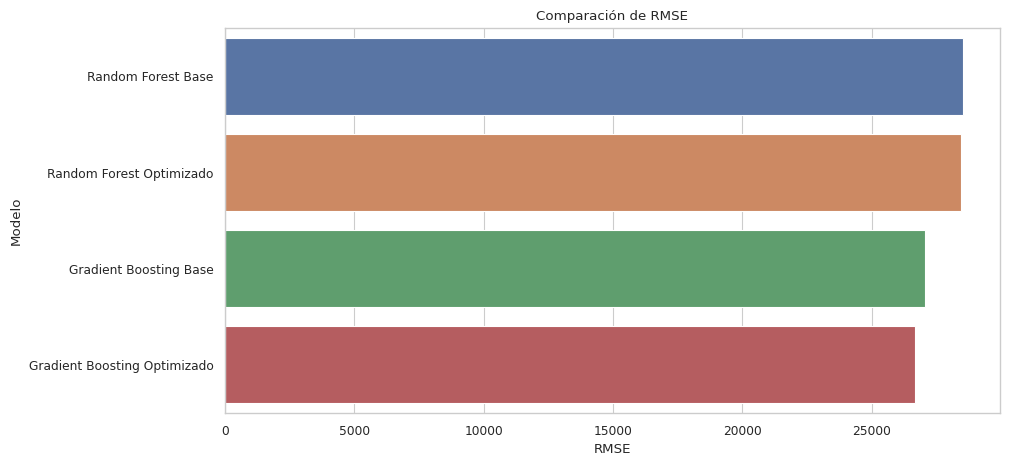

In [ ]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=comparison_results,
    y="Modelo",
    x="RMSE",
    hue="Modelo",
    legend=False
)

plt.title("Comparación de RMSE")
plt.xlabel("RMSE")
plt.ylabel("Modelo")

plt.show()

### Comparación MAE

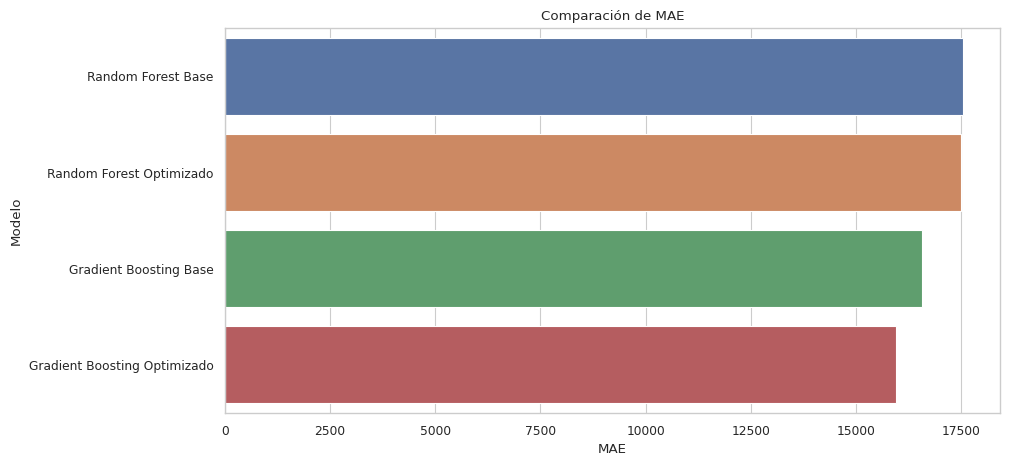

In [ ]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=comparison_results,
    y="Modelo",
    x="MAE",
    hue="Modelo",
    legend=False
)

plt.title("Comparación de MAE")
plt.xlabel("MAE")
plt.ylabel("Modelo")

plt.show()

### Gráfica comparativa R²

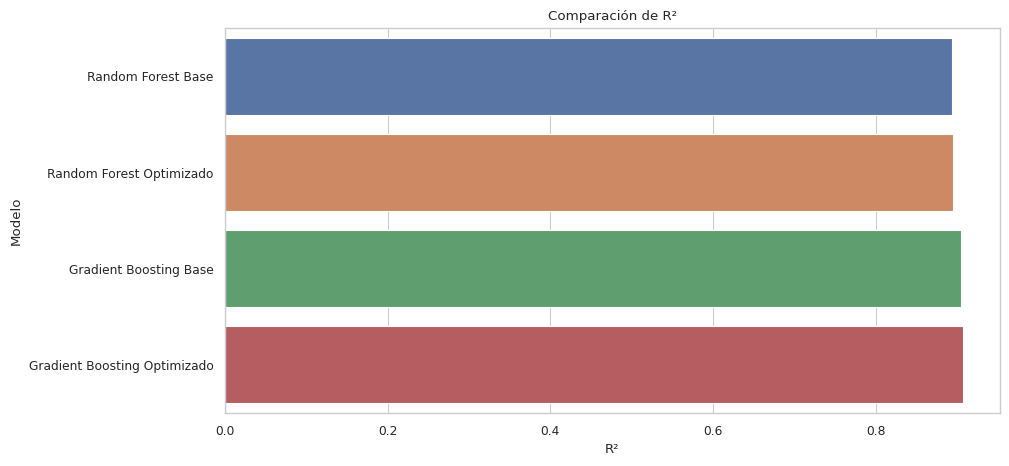

In [ ]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=comparison_results,
    y="Modelo",
    x="R2",
    hue="Modelo",
    legend=False
)

plt.title("Comparación de R²")
plt.xlabel("R²")
plt.ylabel("Modelo")

plt.show()

### Interpretación de métricas

- Un menor RMSE indica que el modelo comete errores más pequeños.
- Un menor MAE indica mejor precisión promedio.
- Un mayor R² indica mejor capacidad para explicar la variabilidad del precio de venta.

El mejor modelo será aquel que combine:

- RMSE bajo
- MAE bajo
- R² alto

### Seleccionar mejor modelo

In [ ]:
best_model_name = comparison_results.sort_values(
    by="RMSE"
).iloc[0]["Modelo"]

print("Mejor modelo:", best_model_name)

Mejor modelo: Gradient Boosting Optimizado


### Definir predicciones del mejor modelo

In [ ]:
best_predictions = gb_pred ##gb_pred es la variable que asigne para las predicciones de Gradient Boosting (optimizado)

### Residuales

In [ ]:
residuals = y_test - best_predictions

### Gráfica de residuales

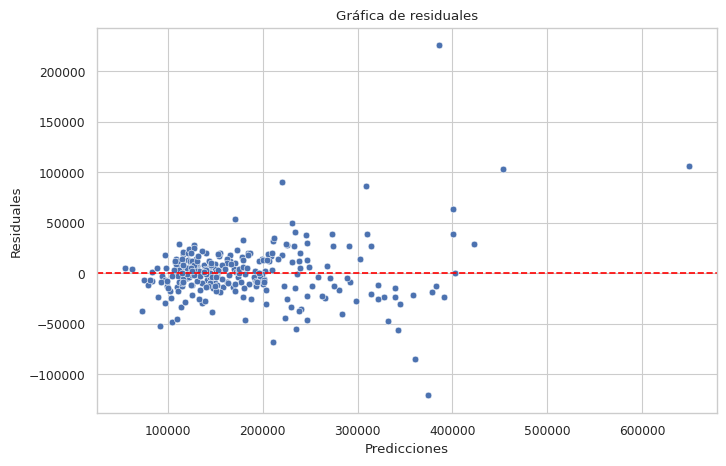

In [ ]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x=best_predictions,
    y=residuals
)

plt.axhline(
    0,
    color="red",
    linestyle="--"
)

plt.title("Gráfica de residuales")
plt.xlabel("Predicciones")
plt.ylabel("Residuales")

plt.show()

### Histograma de residuales

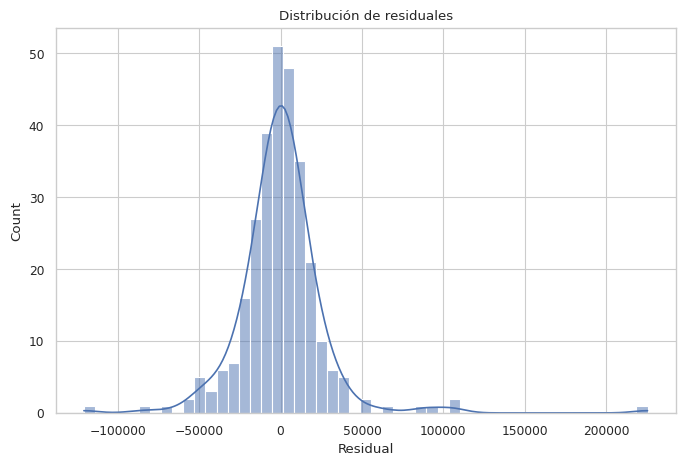

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    residuals,
    kde=True
)

plt.title("Distribución de residuales")
plt.xlabel("Residual")

plt.show()

## Conclusiones

### Respuesta a la pregunta de negocio

La pregunta de negocio planteada al inicio del proyecto fue:

> ¿Es posible predecir el precio de una vivienda utilizando características estructurales y de ubicación de la propiedad?

Con base en los resultados obtenidos, la respuesta es sí.  
Los modelos desarrollados lograron identificar patrones importantes entre las características de las viviendas y su precio de venta.

Variables relacionadas con:

- calidad general de la vivienda,
- tamaño habitable,
- área construida,
- características estructurales,

mostraron una fuerte relación con la variable objetivo (`SalePrice`).

Además, los modelos optimizados mediante GridSearchCV mejoraron el desempeño respecto a las versiones baseline, lo que demuestra que la selección adecuada de hiperparámetros tiene un impacto importante en la capacidad predictiva.

### Reflexión sobre el desempeño del modelo

Los resultados obtenidos indican que el modelo tiene una capacidad predictiva sólida y puede explicar una proporción considerable de la variabilidad en los precios de las viviendas.

El análisis de métricas como:

- RMSE,
- MAE,
- R²,

permitió evaluar tanto el nivel de error como la capacidad explicativa del modelo.

Asimismo, el análisis de residuales mostró una distribución relativamente estable alrededor de cero, lo que sugiere que el modelo captura adecuadamente gran parte de las relaciones presentes en los datos.

Sin embargo, aunque el desempeño es bueno, el modelo aún podría presentar dificultades frente a datos completamente nuevos o propiedades con características poco frecuentes.

### ¿Es un modelo confiable para producción?

El modelo presenta un desempeño suficientemente bueno para considerarse una base sólida para aplicaciones reales.  

No obstante, antes de ser implementado en producción sería necesario realizar validaciones adicionales, tales como:

- pruebas con datos más recientes,
- monitoreo continuo del desempeño,
- evaluación frente a cambios del mercado inmobiliario,
- análisis de estabilidad temporal.

Además, un entorno de producción requeriría controles adicionales para detectar datos atípicos, cambios en la distribución de variables y posibles problemas de drift.

### Limitaciones identificadas

Durante el desarrollo del proyecto se identificaron algunas limitaciones tanto del modelo como del dataset:

### Limitaciones del dataset

- Existencia de valores faltantes en múltiples variables.
- Posibles valores atípicos que pueden afectar el entrenamiento.
- El dataset representa un contexto específico del mercado inmobiliario, por lo que la capacidad de generalización podría ser limitada para otras regiones o periodos de tiempo.

### Limitaciones del modelo

- Los modelos pueden tener dificultades para capturar ciertos patrones extremadamente complejos.
- Algunos algoritmos presentan menor interpretabilidad.
- El desempeño depende considerablemente de la calidad y representatividad de los datos disponibles.

### Propuestas de mejora

Con más tiempo y recursos, podrían implementarse diversas mejoras para incrementar el desempeño y robustez del sistema predictivo.

Algunas propuestas incluyen:

- Probar modelos más avanzados como XGBoost o LightGBM.
- Realizar ingeniería de características más profunda.
- Aplicar técnicas avanzadas de detección y tratamiento de outliers.
- Incorporar validación temporal o validación nested cross-validation.
- Explorar técnicas de selección de variables.
- Implementar explicabilidad del modelo utilizando SHAP o permutation importance.
- Evaluar el desempeño utilizando datasets externos para validar la capacidad de generalización.